In [9]:
from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.quantum_info import Pauli, PauliList
from qiskit_aer.primitives import Estimator
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

In [10]:
#Step 1: map the problem to circuits and operators
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)

qc.draw(output='mpl')

from qiskit.quantum_info import Pauli, PauliList

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables =  [ZZ, ZI, IZ, XX, XI, IX]
print(observables)

#Step 2: Optimize - Not necessary now

[Pauli('ZZ'), Pauli('ZI'), Pauli('IZ'), Pauli('XX'), Pauli('XI'), Pauli('IX')]


In [11]:
#Step 3: Execute on backend
from qiskit_aer.primitives import Estimator
estimator = Estimator()

job = estimator.run([qc] * len(observables), observables)
job.result()

EstimatorResult(values=array([1.        , 0.00585938, 0.00585938, 1.        , 0.03515625,
       0.03515625]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0028654, 'sample_measure_time': 0.0007978, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 14188, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 16, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9999656677246094, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0028654, 'sample_measure_time': 0.0007978, '

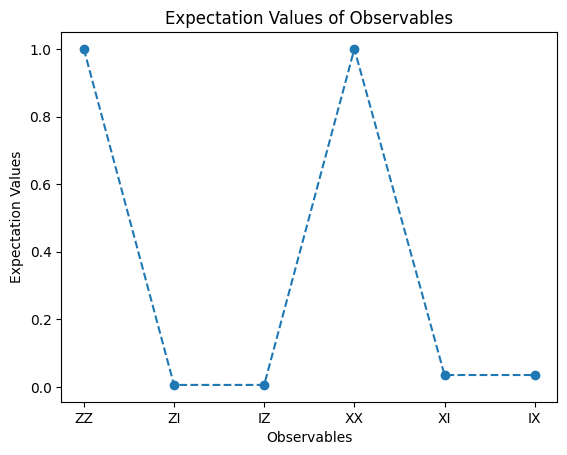

In [12]:
#Step 4: Post-process & plotting
data = ['ZZ', 'ZI', 'IZ', 'XX', 'XI', 'IX']
values = job.result().values

plt.plot(data, values, '--o')
plt.xlabel('Observables')
plt.ylabel('Expectation Values')
plt.title('Expectation Values of Observables')
plt.show()

In [13]:
#Extending Hello World by n-qubit GHZ State
#Step 1: Map problem to circuits and operators
def get_qc_for_n_qubit_GHZ_state(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc

n = 10
qc = get_qc_for_n_qubit_GHZ_state(n)
qc.draw(output='mpl')

operator_strings = ['Z' + 'I' * i + 'Z' + 'I' * (n-2-i) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

['ZZIIIIIIII', 'ZIZIIIIIII', 'ZIIZIIIIII', 'ZIIIZIIIII', 'ZIIIIZIIII', 'ZIIIIIZIII', 'ZIIIIIIZII', 'ZIIIIIIIZI', 'ZIIIIIIIIZ']
9


In [ ]:
#Step 2: Optimize problem for quantum execution
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_name='ibm_kingston'
backend=QiskitRuntimeService().backend(backend_name)
pass_Manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_transpiler = pass_Manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_transpiler._layout) for op in operators]

In [ ]:
#Step 3: Execute on backend
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options = EstimatorOptions()
# REMOVED: options.resilience_level = 1
# REMOVED: options.optimization_level = 1

# This is the correct way to set Dynamical Decoupling in V2
options.dynamical_decoupling.sequence_type = 'XY4'

# If you want to set resilience options (like Pauli Twirling), you do it like this now:
options.twirling.enable_gates = True
options.twirling.num_randomizations = 32

estimator = Estimator(backend, options=options)

job = estimator.run([(qc_transpiler, operators_transpiled_list)])
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d8g0u987jphs739n04fg


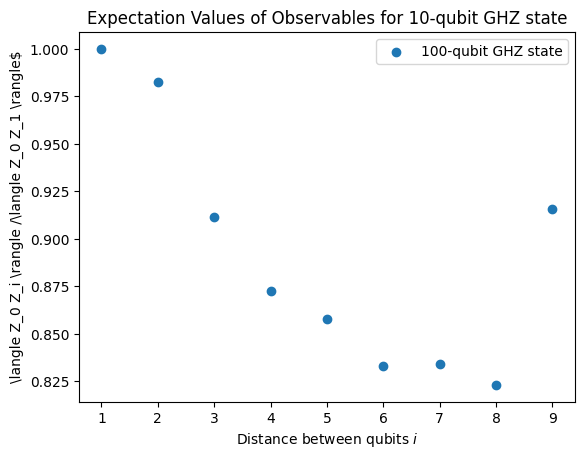

In [15]:
#Step 4: Post-process & plotting
job_id = 'd8g0n33alsvc7392dmd0'
service = QiskitRuntimeService()
job = service.job(job_id)

data = list(range(1, len(operators)+1))
result = job.result()[0]
values = result.data.evs

values = [v/values[0] for v in values]
plt.scatter(data, values, marker='o', label='100-qubit GHZ state')
plt.xlabel('Distance between qubits $i$')
plt.ylabel(r'\langle Z_0 Z_i \rangle /\langle Z_0 Z_1 \rangle$')
plt.title('Expectation Values of Observables for 10-qubit GHZ state')
plt.legend()
plt.show()